In [2]:
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.io import fits
from astropy.convolution import convolve
from astropy.modeling.models import Sersic2D
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
import astropy.units as u
from astropy.constants import c
from reproject import reproject_interp
from scipy.optimize import minimize, least_squares
from scipy.signal import fftconvolve, convolve2d
import dynesty
import dynesty.pool as dypool
from dynesty import plotting as dyplot
import dynesty.utils as dyutil
import pickle
import corner
from cmcrameri import cm
from multiprocessing import Pool
import importlib
import warnings
warnings.simplefilter('ignore', DeprecationWarning)
%matplotlib inline
# seed the random number generator
rstate = np.random.default_rng(111)

from glint.beam import cleanbeam_from_header
from glint.lensing import map_source_to_image, make_grid_arcsec, deflection_SIE_plus_ES
from glint.context import ImageContext
from glint.forward import forward_model_2D_image
from glint.inference import run_emcee
from glint.plotstyle import set_my_plot_style
from glint.sli import build_matrix_lensing

In [3]:
set_my_plot_style()

In [3]:
z=6.024
rad_inn = np.arange(0.003, 0.03, 0.003)
rad_mid = np.arange(0.03, 0.1, 0.01)
rad_out = np.arange(0.12, 0.5, 0.02)

# 配列を結合
rad = np.concatenate((rad_inn, rad_mid, rad_out))

In [4]:
""" 13 free parameters
仮定している事
* One component disk model
* disk thickness = 0
* morphological major axis = kinematic major axis
* morphological center = kinematic center
"""

def create_kinmodel(xs, ys, posAng, inc,              # geometry of disk
                    flux_total, r_scale,              # surface brightness profile
                    v_offset, v_t, r_turn, beta, xi,  # circular velocity profile
                    sigma_0, r_sigma,                 # velocity dispersion profile
                    rad):
    
    ### Here we use an exponential disk model for the surface brightness of the gas ###
    sbProf = np.exp(-1 * rad/r_scale)

    ### We use a relatively complicated rotation curve model with four free parameters. ###
    velProf = v_t * (1 + r_turn/rad)**beta * (1 + (r_turn/rad)**xi)**(-1/xi)
    # return velProf
    ### We assume exponential velocity dispersion profile. ###
    sigmaProf = sigma_0 * np.exp(-1 * rad/r_sigma)

    ### This returns the model
    return velProf, sigmaProf

In [5]:
with open("result/rizzo20_25km_amoeba_maskring.pickle", mode="br") as fi:
    result = pickle.load(fi)
print(result.x)
vel_obs, sigma_obs = create_kinmodel(*result.x[:13], rad) * u.km / u.s

[-9.04788363e-03 -1.80297282e-03 -3.25840620e+01  3.02171535e+01
  1.98570796e+02  1.32911106e-01 -1.66051130e+01  3.48842507e+02
  1.43778920e-02  6.71257120e-01  2.17180221e+00  1.31246566e+02
  3.05805398e-01  1.93559108e-01  2.85631110e-01  1.16440083e+00
  2.14886476e-01 -2.78146312e+01  3.64005281e-03]


In [ ]:
# pressure support correction
vel_a_sq = rad * sigma_obs**2 * (2/result.x[12] + 1/result.x[5])

In [7]:
vel_corr = np.sqrt(vel_obs**2 + vel_a_sq)

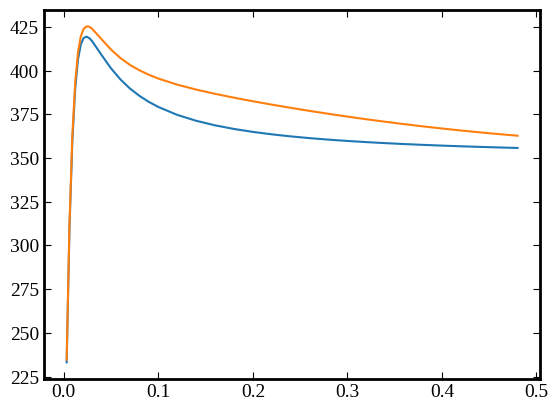

In [8]:
plt.plot(rad, vel_obs)
plt.plot(rad, vel_corr)

In [9]:
rad_kpc = rad * asc2kpc

In [2]:
46/25515

0.0018028610621203215

In [10]:
# star
def sersic(M_bulge, r_eff, n, radius): # /Msun, /kpc, /kpc
    b = 2 * n - 1/3 + 4/405/n + 46/25515/n**2  # For n > 0.36 (Ciotti & Bertin 1999)
    p = 1.0 - 0.6097/n + 0.05563/n**2  # For 0.6 < n < 10 (Terzic & Graham 2005)
    vel_sq = G * (M_bulge*M_sun) / radius * gammainc(n*(3-p), b*((radius/r_eff).value)**(1/n))
    return vel_sq.to(u.km**2/u.s**2)

In [11]:
# Disk model
# def expdisk(M_disk, r_disk, radius): # /Msun, /kpc, /kpc
#     y = radius / r_disk
#     vel_sq = 2 * G * (M_disk*M_sun) / r_disk * y**2 * (i0(y) * k0(y) - i1(y) * k1(y))
#     return vel_sq.to(u.km**2/u.s**2)

def expdisk(M_disk, r_disk, radius): # /Msun, /kpc, /kpc
    y = (radius / r_disk / 2).value
    vel_sq = 2 * G * (M_disk*M_sun) * y**2 / r_disk * (i0(y) * k0(y) - i1(y) * k1(y))
    return vel_sq.to(u.km**2/u.s**2)

In [12]:
# Dark matter (NFW)
H = cosmo.H(z=4.2)
rho_crit = 3 * H**2 / 8 / np.pi / G

def nfw(M_200, c, radius):  # /Msun, /kpc
    # c = 3 # fix
    
    M_200  = M_200 * M_sun
    r_200 = ((3 * M_200 / 800 / np.pi / rho_crit)**(1/3)).to(u.kpc)
    
    vel_200_sq = G * M_200 / r_200
    x  =  radius / r_200
    conv = (np.log(1 + c * x) - (c * x / (1 + c * x))) / (x * (np.log(1 + c) - (c / (1 + c))))
    vel_sq = vel_200_sq * conv
    
    return vel_sq.to(u.km**2/u.s**2)

# dynesty fitting

In [13]:
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [14]:
vel_corr

<Quantity [234.65361808, 312.41740413, 362.38400593, 392.96805469,
           410.44561346, 419.66559968, 423.92918194, 425.30763484,
           425.04822514, 423.88870893, 417.88262472, 411.96737178,
           407.12145998, 403.25839955, 400.14974874, 397.59577927,
           395.44636397, 391.95838674, 389.13801651, 386.70205961,
           384.50172815, 382.45821523, 380.53007896, 378.69611235,
           376.94604875, 375.27539713, 373.68253392, 372.16706457,
           370.72891543, 369.36785171, 368.08324546, 366.87398931,
           365.73849348, 364.67472823, 363.68028862, 362.75246775] km / s>

In [14]:
def prior_transform(u):

    x = np.zeros(u.shape)
    
    # M_bulge (uniform [1e7:1e12])
    x[0] = 10 ** (u[0] * 5 + 7)
    
    # r_eff (uniform [0.04:2])
    x[1] = u[1] * 1
    
    # n (uniform [0.5:4.5])
    x[2] = u[2] * 9.5 + 0.5
    
    # M_disk (uniform [1e8.5:1e12])
    x[3] = 10 ** (u[3] * 3.5 + 8.5)
    
    # M_dm (uniform [1e10, 1e13])
    x[4] = 10 ** (u[4] * 4 + 10)
    
    # c (uniform [2:4])
    # x[5] = u[5] * 2 + 2
    
    return x

num = len(vel_corr)
def loglike(params):
    M_bulge, r_eff, n,\
    M_disk,\
    M_dm = params    
    # M_dm, c = params   
    vel_sq_bulge = sersic(M_bulge, r_eff*u.kpc, n, rad_kpc)
    vel_sq_disk  = expdisk(M_disk, 1.35*u.kpc, rad_kpc)
    vel_sq_dm = nfw(M_dm, 3, rad_kpc)
    
    blob = np.zeros((3, num))
    blob[0] = vel_sq_bulge
    blob[1] = vel_sq_disk
    blob[2] = vel_sq_dm
    
    v_circ = np.sqrt(vel_sq_bulge + vel_sq_disk + vel_sq_dm)
    chisq = np.sum(((vel_corr-v_circ)/(40*u.km/u.s))**2)
    if np.isnan(chisq):
        return -np.inf, blob
    return -0.5 * chisq, blob

In [16]:
loglike([-1.2e10, 0.22*u.kpc, 2.2, 1.3e10, 1.7e12])

(-inf,
 array([[-3.04908428e+04, -5.02803714e+04, -6.35764079e+04,
         -7.28053870e+04, -7.92965397e+04, -8.38583029e+04,
         -8.70171759e+04, -8.91328541e+04, -9.04599277e+04,
         -9.11835690e+04, -9.07715889e+04, -8.79942529e+04,
         -8.42197442e+04, -8.00980259e+04, -7.59504296e+04,
         -7.19362515e+04, -6.81309705e+04, -6.12466753e+04,
         -5.53193975e+04, -5.02441917e+04, -4.58929862e+04,
         -4.21466540e+04, -3.89033134e+04, -3.60786435e+04,
         -3.36037485e+04, -3.14225423e+04, -2.94893250e+04,
         -2.77667349e+04, -2.62240860e+04, -2.48360428e+04,
         -2.35815709e+04, -2.24431089e+04, -2.14059130e+04,
         -2.04575379e+04, -1.95874227e+04, -1.87865601e+04],
        [ 1.55387619e+01,  5.29513675e+01,  1.07038395e+02,
          1.75044652e+02,  2.55058424e+02,  3.45617042e+02,
          4.45539486e+02,  5.53838786e+02,  6.69670208e+02,
          7.92297976e+02,  1.24230401e+03,  1.74186579e+03,
          2.27680011e+03,  2.836

In [21]:
# Run
with dypool.Pool(16, loglike, prior_transform) as pool:
    sampler = dynesty.DynamicNestedSampler(pool.loglike, pool.prior_transform, ndim=5, pool=pool, blob=True)
    sampler.run_nested(nlive_init=1024, wt_kwargs={'pfrac':1.0}, dlogz_init=1e-6,
                       maxcall=1e9, stop_kwargs={'pfrac':1.0},
                       print_progress=True)

31150it [03:06, 166.98it/s, batch: 4 | bound: 38 | nc: 1 | ncall: 379785 | eff(%):  8.097 | loglstar: -5.396 < -0.717 < -2.262 | logz: -11.186 +/-  0.071 | stop:  0.859]            


In [74]:
results = sampler.results
samples = sampler.results.samples
weights = sampler.results.importance_weights()
blob = sampler.results.blob

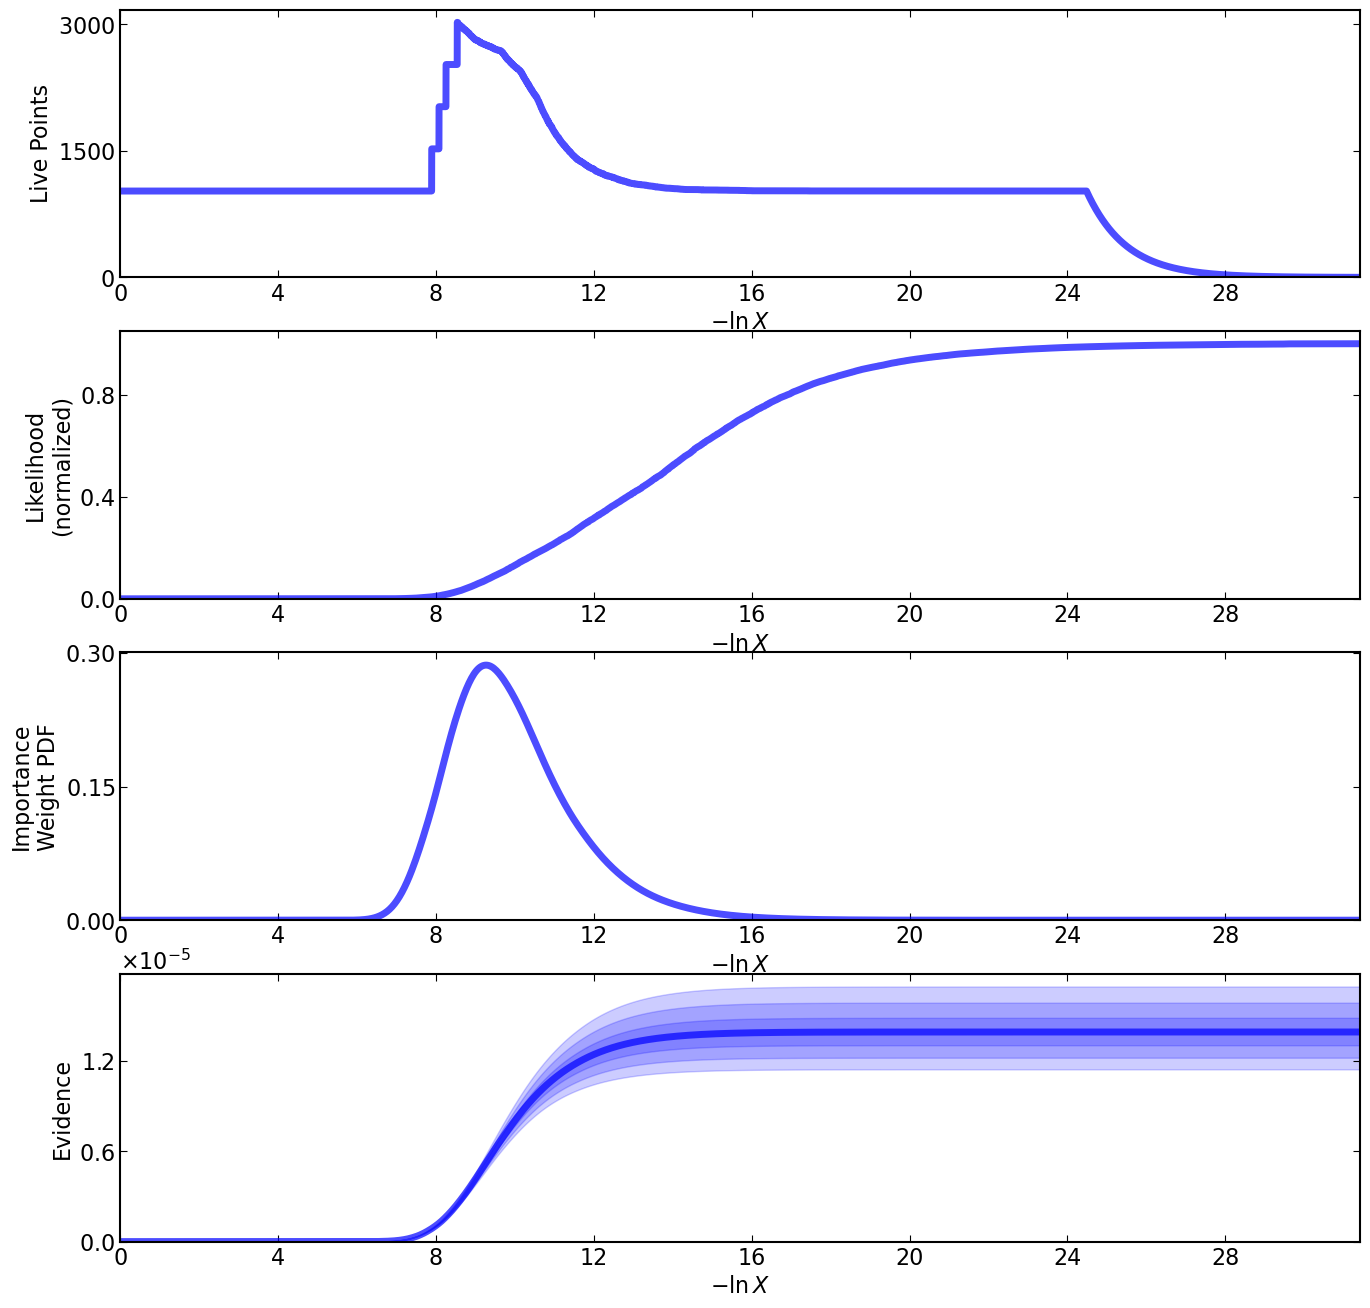

In [75]:
_,_ = dyplot.runplot(results)

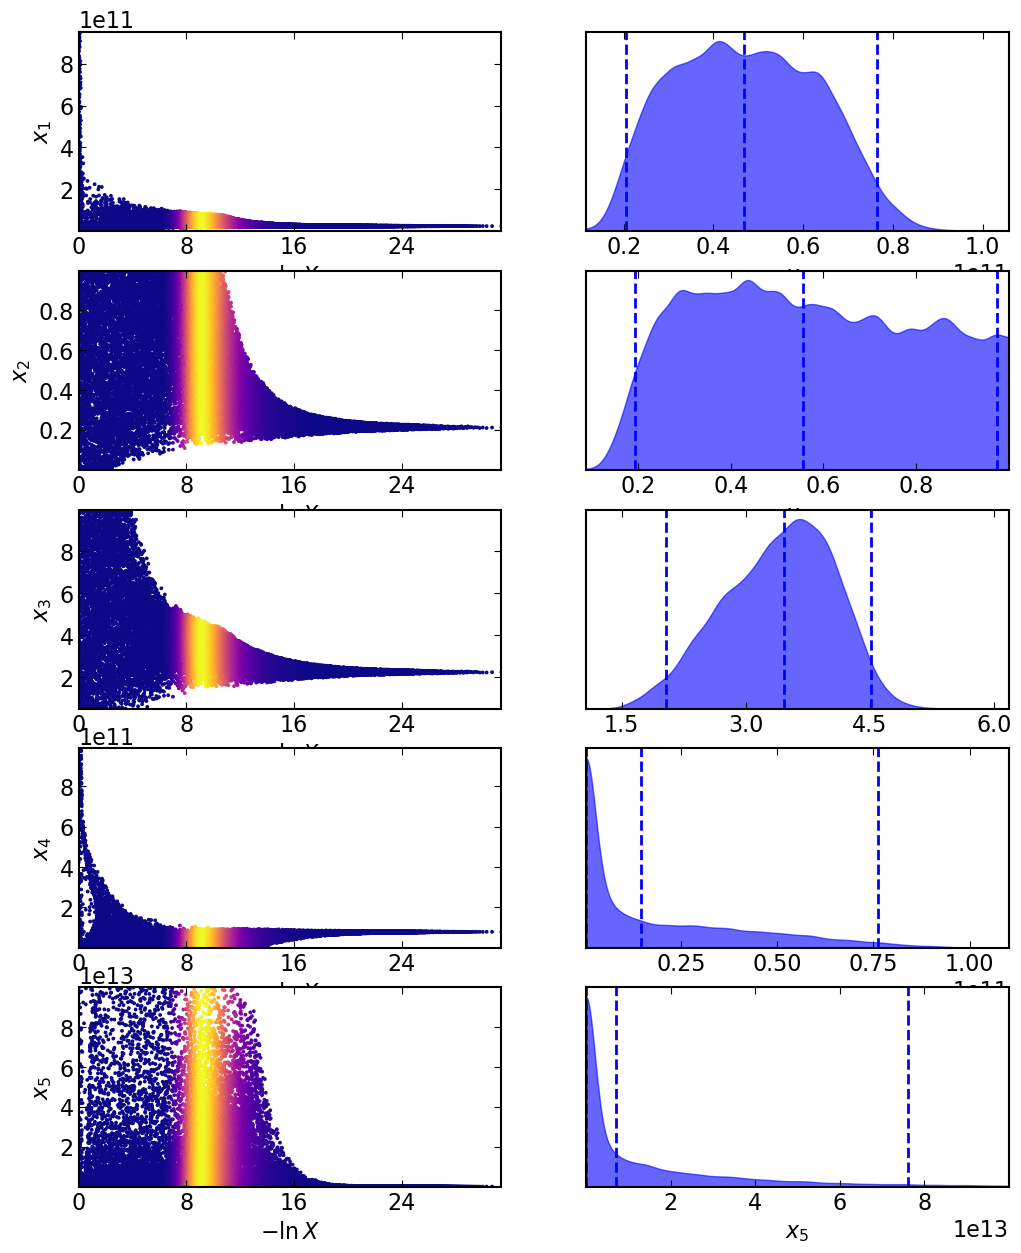

In [76]:
_,_ = dyplot.traceplot(results)

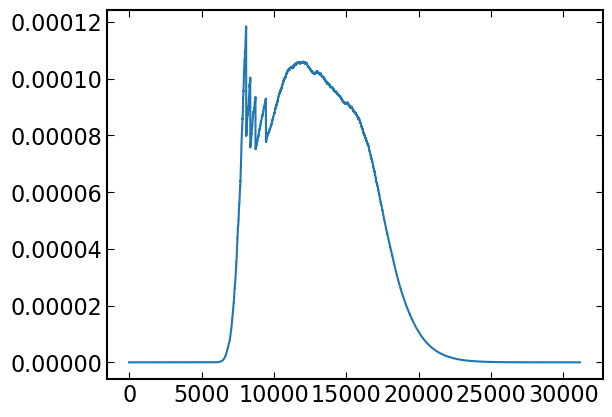

In [77]:
plt.plot(weights)

In [78]:
with open("result/decomposition_dynesty_1e-6.pickle", mode="wb") as fo:
    pickle.dump(sampler.results, fo)

In [ ]:
with open("result/decomposition_dynesty_1e-6.pickle", mode="wb") as fo:
    pickle.dump(sampler.results, fo)

In [79]:
samples_intr = samples
for col in [0, 3, 4]:
    samples_intr[:,col] = np.log10(samples[:,col])

quantiles = [dyfunc.quantile(samps, [0.16, 0.50, 0.84], weights=weights)
             for samps in samples_intr.T]

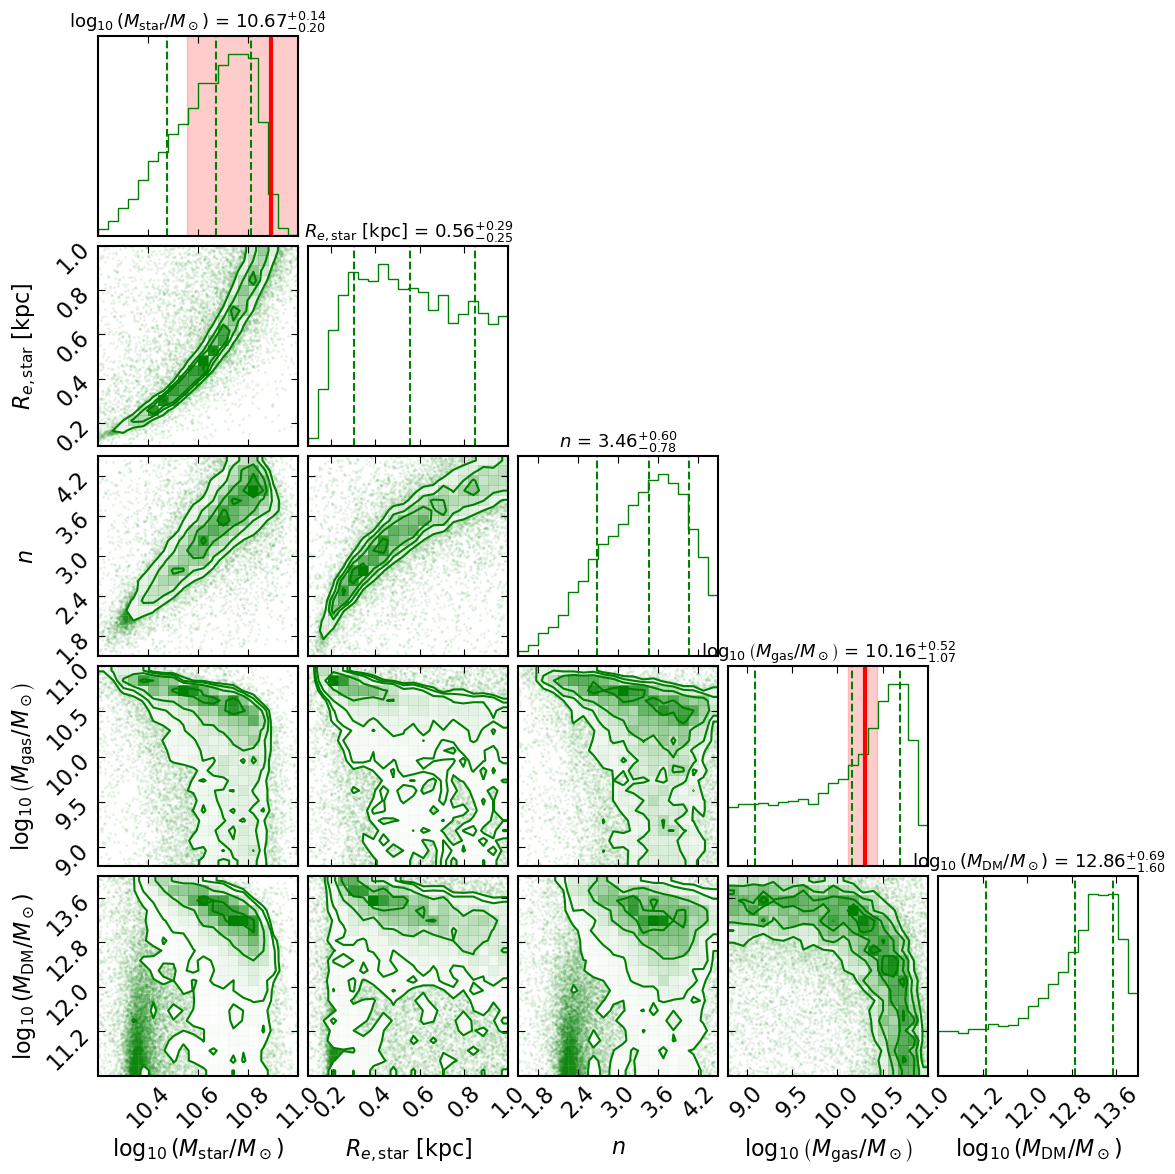

In [80]:
fig = corner.corner(samples_intr,
                    labels=[r"$\log_{10} \left(M_\text{star}/M_\odot\right)$", 
                            r"$R_{e, \text{star}}$ [kpc]",
                            r"$n$",
                            r"$\log_{10} \left(M_\text{gas}/M_\odot\right)$",
                            r"$\log_{10} \left(M_\text{DM}/M_\odot\right)$",
                            r"$c$"],
                    bins=20,
                    range=[(10.2, 11.), (0.1, 1.0), (1.5, 4.5), (8.8, 11.), (10.4, 14)],
                    show_titles=True,
                    quantiles=[0.16, 0.5, 0.84],
                    title_kwargs={"fontsize":13},
                    weights=weights,
                    color="green",
                    )
# fig.tight_layout()
axes = np.array(fig.axes).reshape((5, 5))
axes[0,0].axvline(np.log10(7.8e10), color='red', lw=3)
axes[0,0].fill_betweenx(np.arange(-100,100), np.log10(3.6e10), np.log10(16.2e10), color='red', alpha=0.2)
axes[3,3].axvline(np.log10(2.0e10), color='red', lw=3)
axes[3,3].fill_betweenx(np.arange(-100,100), np.log10(1.3e10), np.log10(2.7e10), color='red', alpha=0.2)

fig.savefig("result/fig/decomposition_corner.png", dpi=300, bbox_inches="tight", pad_inches=0.05)

In [15]:
def calc_percentile(samples, weights, percentile):
    idx = np.argsort(samples)
    wht = weights[idx]
    cdf = np.concatenate([[0], np.cumsum(wht)[:-1]])
    cdf /= cdf[-1]
    return np.interp(percentile, cdf, samples[idx])

In [25]:
calc_percentile(samples[:,1], weights, [0.16, 0.50, 0.84])

array([0.1601506 , 0.20836274, 0.2655082 ])

In [58]:
blob.shape

(27957, 3, 36)

In [59]:
blob[:,0,0]

array([1.39205137e+08, 1.11229700e+08, 5.06963942e+07, ...,
       5.77090674e+04, 5.80234223e+04, 5.78550773e+04])

In [17]:
vel_sq_bulge = np.array([calc_percentile(np.array(blob[:,0,rad]), weights, [0.16, 0.50, 0.84]) for rad in range(len(rad_kpc))]).T
vel_sq_disk  = np.array([calc_percentile(np.array(blob[:,1,rad]), weights, [0.16, 0.50, 0.84]) for rad in range(len(rad_kpc))]).T
vel_sq_dm    = np.array([calc_percentile(np.array(blob[:,2,rad]), weights, [0.16, 0.50, 0.84]) for rad in range(len(rad_kpc))]).T
vel_sq_total = np.array([calc_percentile(np.array(blob[:,0,rad]+blob[:,1,rad]+blob[:,2,rad]), weights, [0.16, 0.50, 0.84]) for rad in range(len(rad_kpc))]).T

NameError: name 'blob' is not defined

In [ ]:
def prior_transform(u):

    x = np.zeros(u.shape)
    
    # M_bulge (uniform [1e7:1e12])
    x[0] = 10 ** (u[0] * 5 + 7)
    
    # r_eff (uniform [0.04:2])
    x[1] = u[1] * 1
    
    # n (uniform [0.5:4.5])
    x[2] = u[2] * 9.5 + 0.5
    
    # M_disk (uniform [1e8.5:1e12])
    x[3] = scipy.stats.norm.ppf(u[3], loc=2.0e10, scale=0.7e10)
    
    # M_dm (uniform [1e10, 1e13])
    x[4] = 10 ** (u[4] * 4 + 10)
    
    # c (uniform [2:4])
    # x[5] = u[5] * 2 + 2
    
    return x

# Run
with dypool.Pool(16, loglike, prior_transform) as pool:
    sampler2 = dynesty.DynamicNestedSampler(pool.loglike, pool.prior_transform, ndim=5, pool=pool, blob=True)
    sampler2.run_nested(nlive_init=1024, wt_kwargs={'pfrac':1.0}, dlogz_init=1e-6,
                       maxcall=1e9, stop_kwargs={'pfrac':1.0},
                       print_progress=True)

8234it [00:25, 324.52it/s, batch: 0 | bound: 25 | nc: 47 | ncall: 73379 | eff(%): 11.067 | loglstar:   -inf < -3.833 <    inf | logz: -12.040 +/-  0.083 | dlogz:  2.967 >  0.000]   Process ForkPoolWorker-32:
Process ForkPoolWorker-25:
Process ForkPoolWorker-24:
Process ForkPoolWorker-31:
Process ForkPoolWorker-30:
Process ForkPoolWorker-22:
Process ForkPoolWorker-29:
Process ForkPoolWorker-19:
Process ForkPoolWorker-27:
Process ForkPoolWorker-17:
Process ForkPoolWorker-18:
Process ForkPoolWorker-20:
Process ForkPoolWorker-21:
Process ForkPoolWorker-23:
Process ForkPoolWorker-28:
Process ForkPoolWorker-26:
Traceback (most recent call last):
Traceback (most recent call last):

Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
T

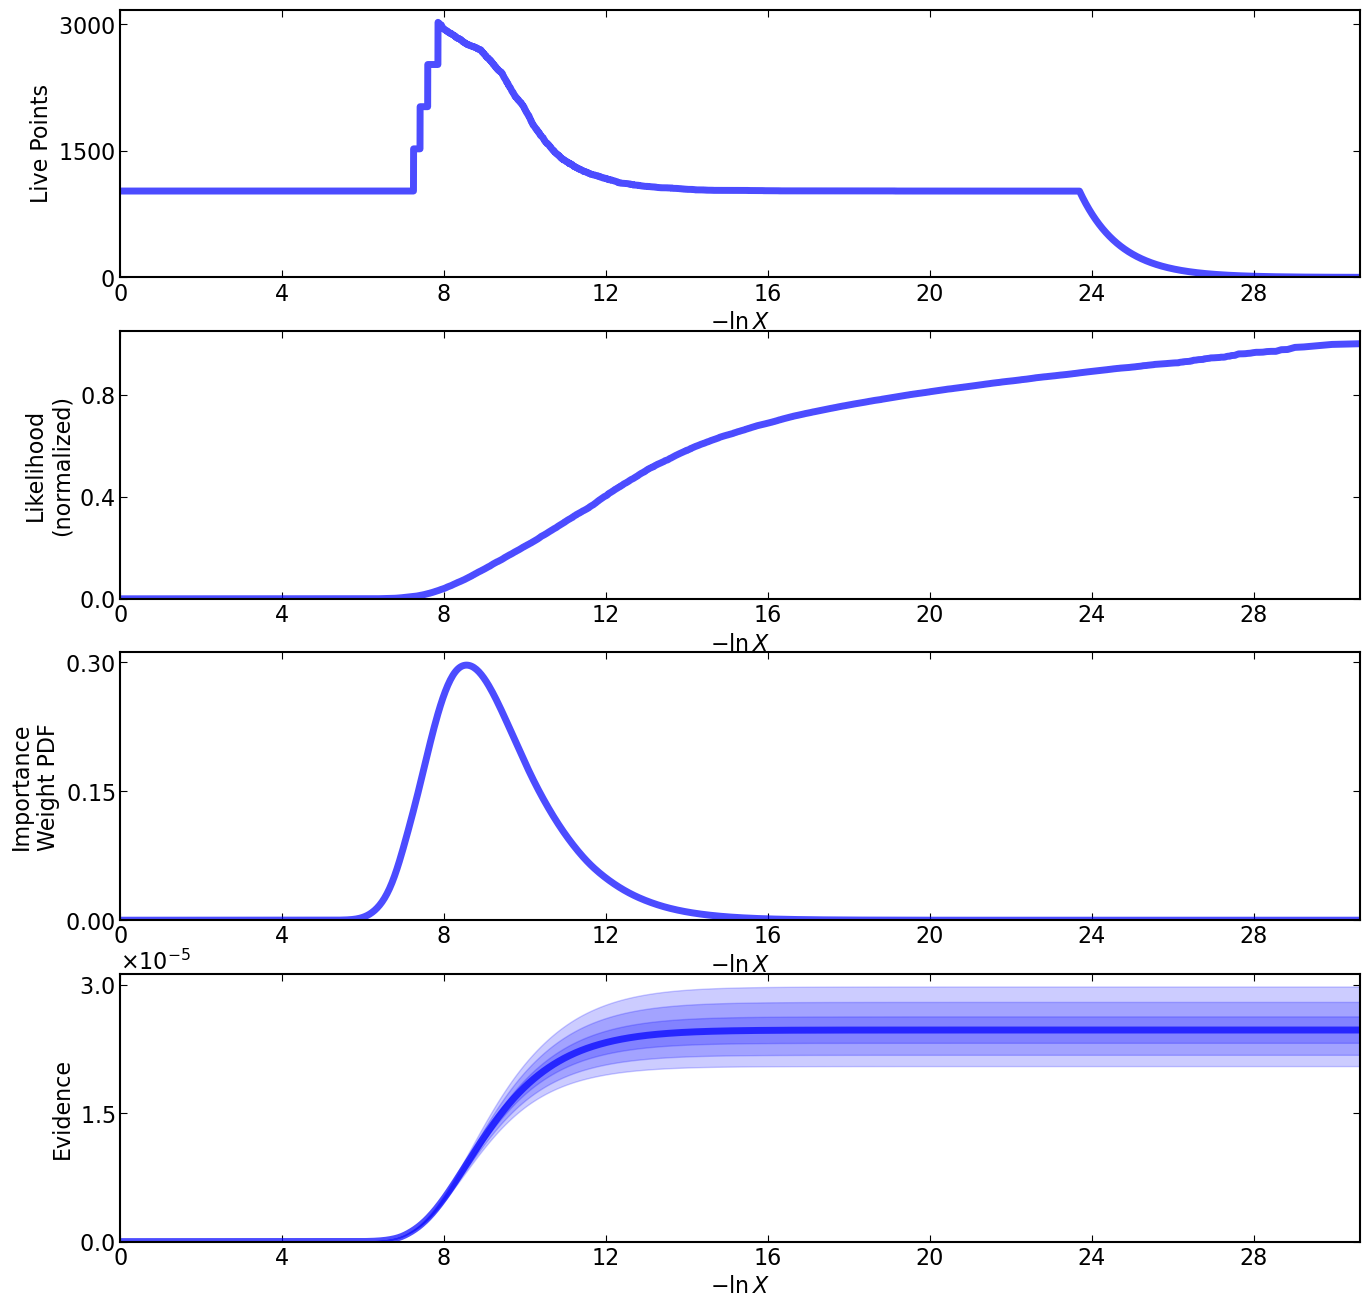

In [ ]:
results2 = sampler2.results
samples2 = sampler2.results.samples
weights2 = sampler2.results.importance_weights()
blob2 = sampler2.results.blob
_,_ = dyplot.runplot(results2)

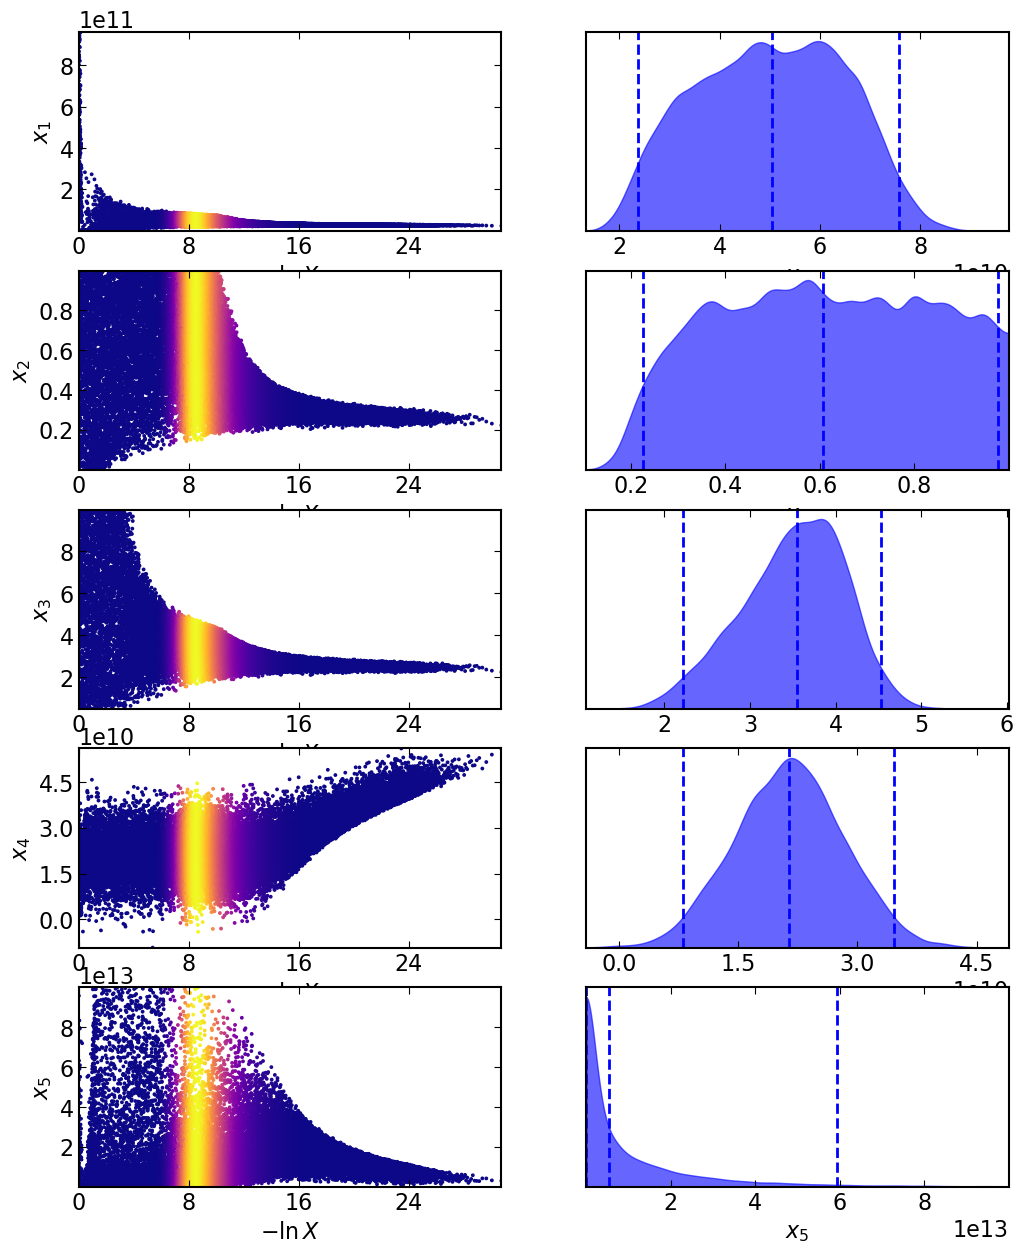

In [47]:
_,_ = dyplot.traceplot(results2)

In [16]:
with open("result/decomposition_mgasprior_dynesty_1e-6.pickle", mode="wb") as fo:
    pickle.dump(sampler2.results, fo)
samples_intr2 = samples2
for col in [0, 4]:
    samples_intr2[:,col] = np.log10(samples2[:,col])
samples_intr2[:,3] /= 1e10
quantiles2 = [dyfunc.quantile(samps, [0.16, 0.50, 0.84], weights=weights2)
             for samps in samples_intr2.T]

NameError: name 'sampler2' is not defined

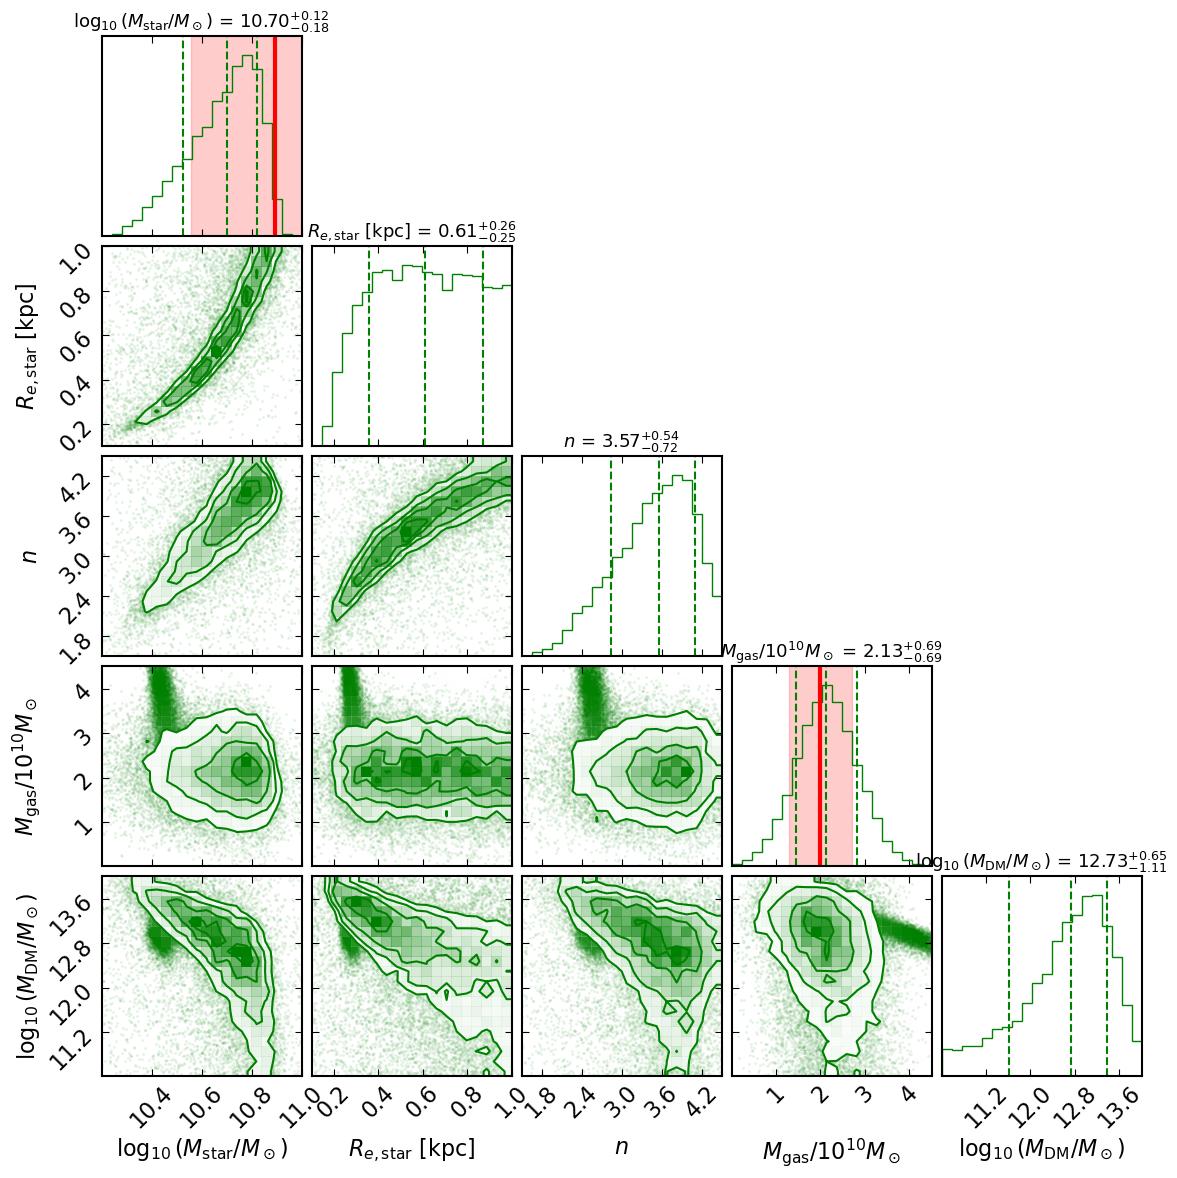

In [20]:
fig2 = corner.corner(samples_intr2,
                    labels=[r"$\log_{10} \left(M_\text{star}/M_\odot\right)$", 
                            r"$R_{e, \text{star}}$ [kpc]",
                            r"$n$",
                            r"$M_\text{gas} /10^{10} M_\odot$",
                            r"$\log_{10} \left(M_\text{DM}/M_\odot\right)$",],
                    bins=20,
                    range=[(10.2, 11.), (0.1, 1.0), (1.5, 4.5), (0, 4.5), (10.4, 14)],
                    show_titles=True,
                    quantiles=[0.16, 0.5, 0.84],
                    title_kwargs={"fontsize":13},
                    weights=weights2,
                    color="green",
                    )
# fig.tight_layout()
axes = np.array(fig2.axes).reshape((5, 5))
axes[0,0].axvline(np.log10(7.8e10), color='red', lw=3)
axes[0,0].fill_betweenx(np.arange(-100,100), np.log10(3.6e10), np.log10(16.2e10), color='red', alpha=0.2)
axes[3,3].axvline(2.0, color='red', lw=3)
axes[3,3].fill_betweenx(np.arange(-100,100), 1.3, 2.7, color='red', alpha=0.2)

fig2.savefig("result/fig/decomposition_mgasprior_corner.png", dpi=300, bbox_inches="tight", pad_inches=0.05)

In [18]:
def prior_transform(u):

    x = np.zeros(u.shape)
    
    # M_bulge (uniform [1e7:1e12])
    x[0] = scipy.stats.norm.ppf(u[0], loc=7.8e10, scale=4.2e10)
    
    # r_eff (uniform [0.04:2])
    x[1] = u[1] * 1
    
    # n (uniform [0.5:4.5])
    x[2] = u[2] * 9.5 + 0.5
    
    # M_disk (uniform [1e8.5:1e12])
    x[3] = scipy.stats.norm.ppf(u[3], loc=2.0e10, scale=0.7e10)
    
    # M_dm (uniform [1e10, 1e13])
    x[4] = 10 ** (u[4] * 4 + 10)
    
    # c (uniform [2:4])
    # x[5] = u[5] * 2 + 2
    
    return x

# Run
with dypool.Pool(16, loglike, prior_transform) as pool:
    sampler3 = dynesty.DynamicNestedSampler(pool.loglike, pool.prior_transform, ndim=5, pool=pool, blob=True)
    sampler3.run_nested(nlive_init=1024, wt_kwargs={'pfrac':1.0}, dlogz_init=1e-6,
                       maxcall=1e9, stop_kwargs={'pfrac':1.0},
                       print_progress=True)

28773it [04:18, 111.26it/s, batch: 4 | bound: 18 | nc: 1 | ncall: 580336 | eff(%):  4.911 | loglstar: -5.702 < -1.072 < -2.541 | logz: -9.132 +/-  0.060 | stop:  0.888]             


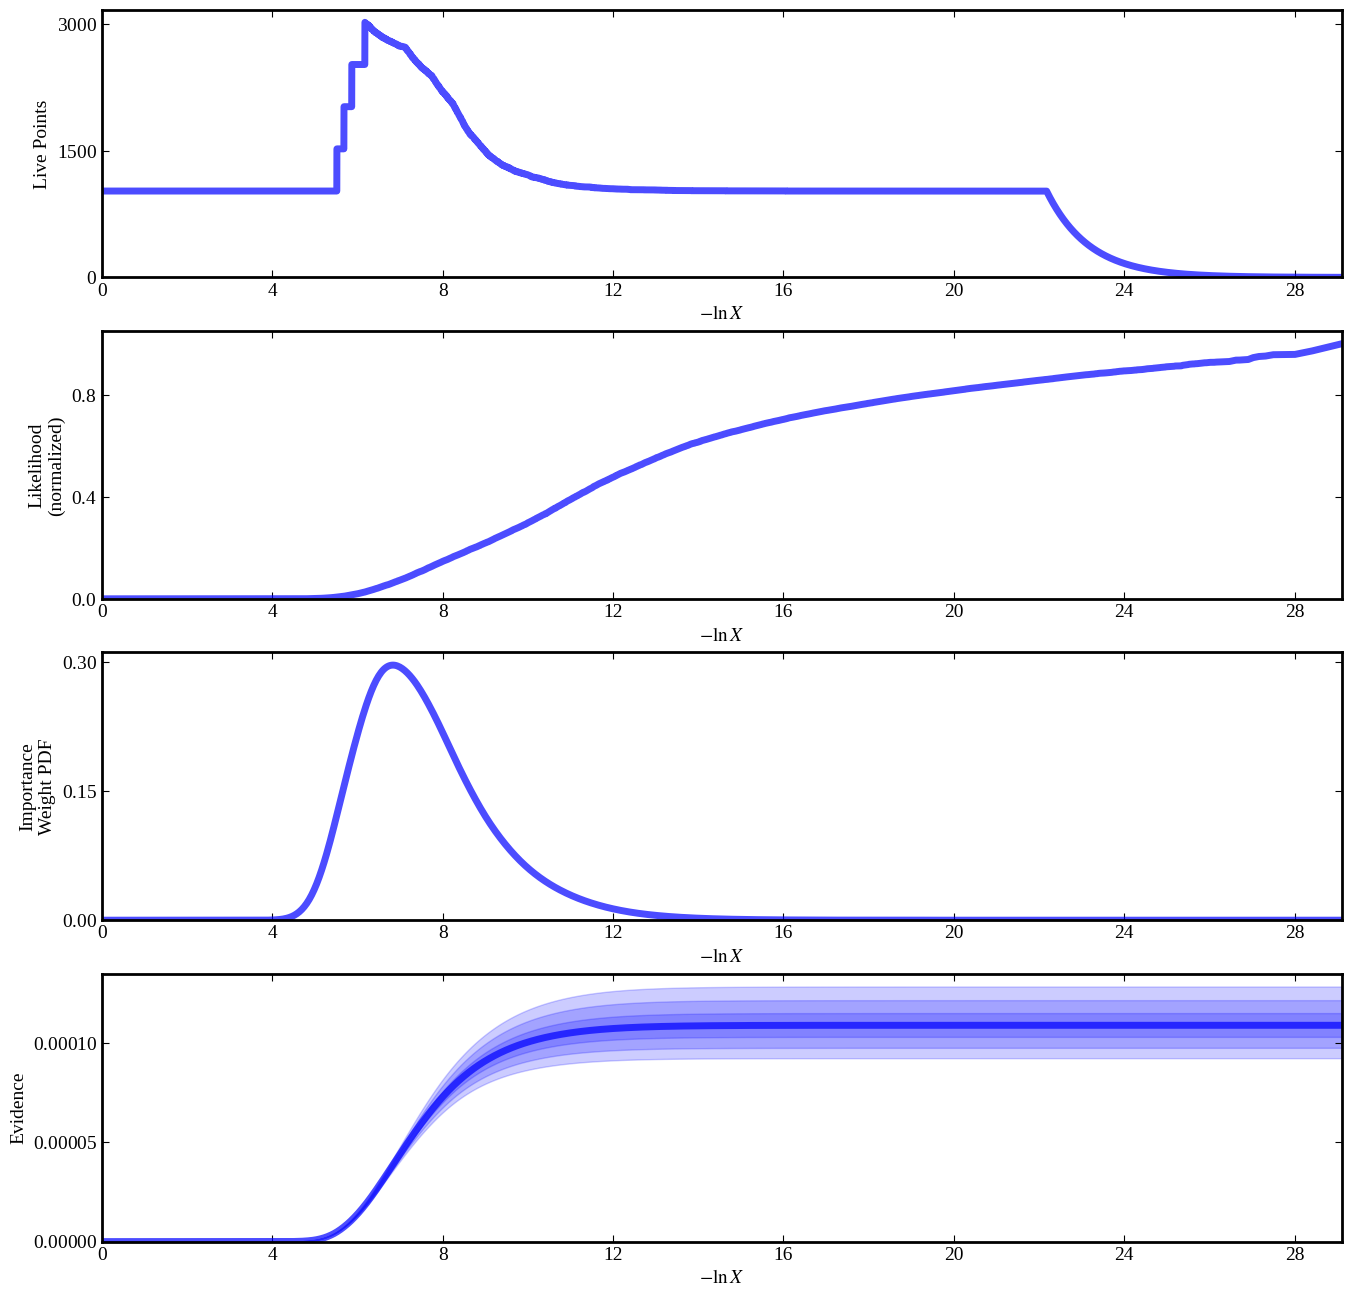

In [19]:
results3 = sampler3.results
samples3 = sampler3.results.samples
weights3 = sampler3.results.importance_weights()
blob3 = sampler3.results.blob
_,_ = dyplot.runplot(results3)

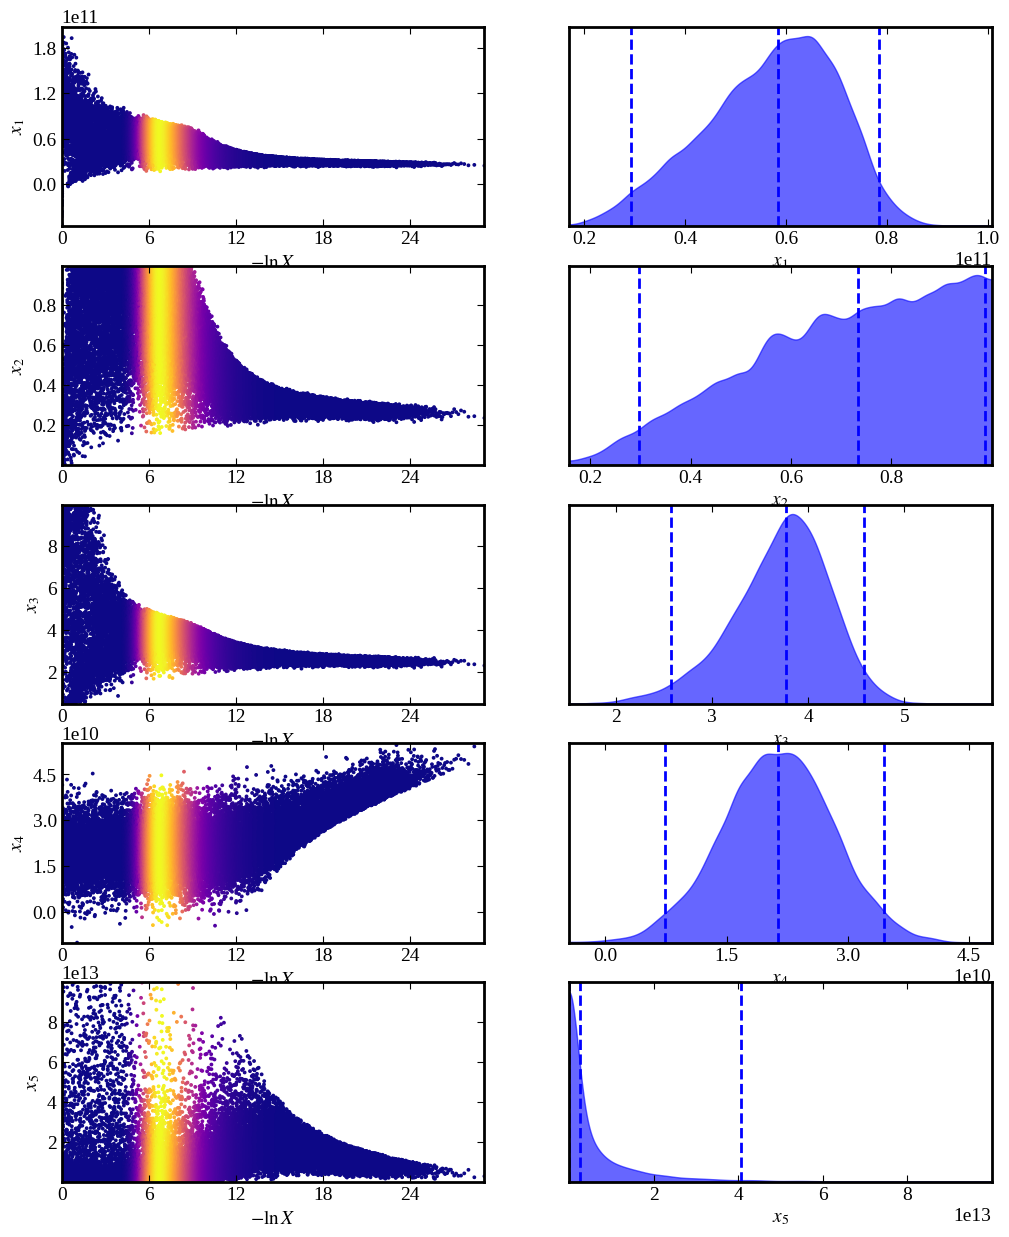

In [20]:
_,_ = dyplot.traceplot(results3)

In [21]:
vel_sq_bulge = np.array([calc_percentile(np.array(blob3[:,0,rad]), weights3, [0.16, 0.50, 0.84]) for rad in range(len(rad_kpc))]).T
vel_sq_disk  = np.array([calc_percentile(np.array(blob3[:,1,rad]), weights3, [0.16, 0.50, 0.84]) for rad in range(len(rad_kpc))]).T
vel_sq_dm    = np.array([calc_percentile(np.array(blob3[:,2,rad]), weights3, [0.16, 0.50, 0.84]) for rad in range(len(rad_kpc))]).T
vel_sq_total = np.array([calc_percentile(np.array(blob3[:,0,rad]+blob3[:,1,rad]+blob3[:,2,rad]), weights3, [0.16, 0.50, 0.84]) for rad in range(len(rad_kpc))]).T

In [22]:
with open("result/decomposition_mgasmstarprior_dynesty_1e-6.pickle", mode="wb") as fo:
    pickle.dump(sampler3.results, fo)
samples_intr3 = samples3
for col in [4]:
    samples_intr3[:,col] = np.log10(samples3[:,col])
samples_intr3[:,0] /= 1e10
samples_intr3[:,3] /= 1e10
quantiles3 = [dyfunc.quantile(samps, [0.16, 0.50, 0.84], weights=weights3)
             for samps in samples_intr3.T]

./result/fig/decomposition_mgasmstarprior_corner.pdf created


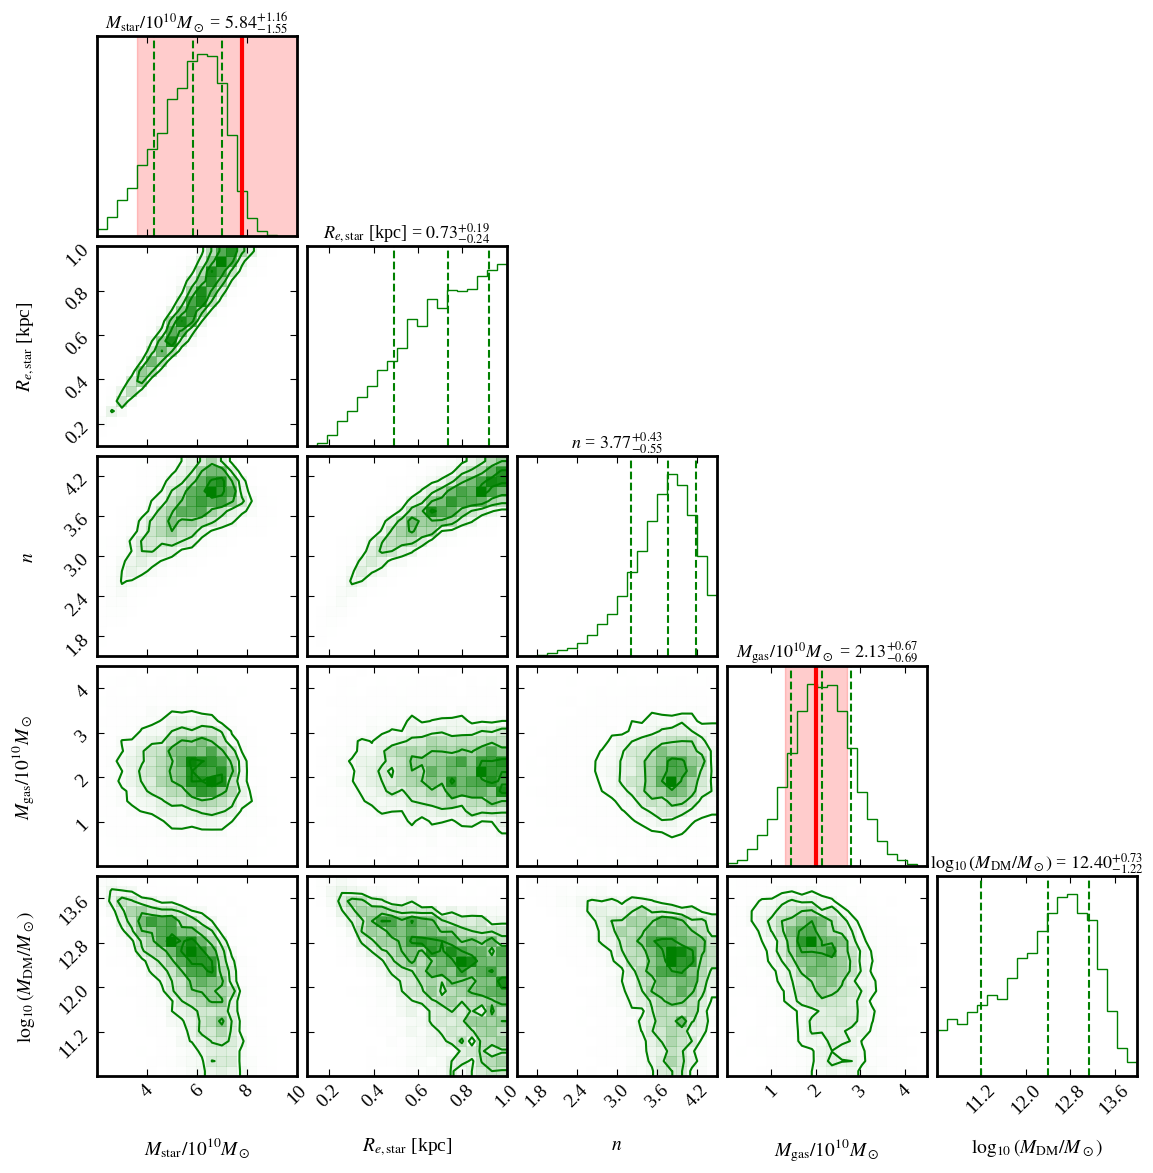

In [23]:
fig3 = corner.corner(samples_intr3,
                    labels=[r"$M_\text{star} /10^{10} M_\odot$",
                            r"$R_{e, \text{star}}$ [kpc]",
                            r"$n$",
                            r"$M_\text{gas} /10^{10} M_\odot$",
                            r"$\log_{10} \left(M_\text{DM}/M_\odot\right)$",],
                    bins=20,
                    range=[(2, 10.), (0.1, 1.0), (1.5, 4.5), (0, 4.5), (10.4, 14)],
                    show_titles=True,
                    quantiles=[0.16, 0.5, 0.84],
                    title_kwargs={"fontsize":13},
                    weights=weights3,
                    color="green",
                    plot_datapoints=False
                    )
# fig.tight_layout()
axes = np.array(fig3.axes).reshape((5, 5))
axes[0,0].axvline(7.8, color='red', lw=3)
axes[0,0].fill_betweenx(np.arange(-100,100), 3.6, 16.2, color='red', alpha=0.2)
axes[3,3].axvline(2.0, color='red', lw=3)
axes[3,3].fill_betweenx(np.arange(-100,100), 1.3, 2.7, color='red', alpha=0.2)

fig3.savefig("result/fig/decomposition_mgasmstarprior_corner.pdf", dpi=300, bbox_inches="tight", pad_inches=0.05)
print("./result/fig/decomposition_mgasmstarprior_corner.pdf created")

./result/fig/decomposition_mgasprior_rotcur.pdf created


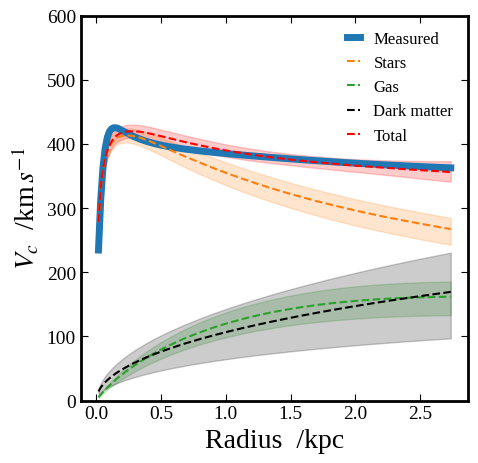

In [24]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(rad_kpc, vel_corr, label="Measured", lw=5)
ax.plot(rad_kpc, np.sqrt(vel_sq_bulge)[1], ls="--", c="tab:orange", label="Stars")
ax.fill_between(rad_kpc.value, np.sqrt(vel_sq_bulge)[0], np.sqrt(vel_sq_bulge)[2], color="tab:orange", alpha=0.2)
ax.plot(rad_kpc, np.sqrt(vel_sq_disk)[1], ls="--", c="tab:green", label="Gas")
ax.fill_between(rad_kpc.value, np.sqrt(vel_sq_disk)[0], np.sqrt(vel_sq_disk)[2], color="tab:green", alpha=0.2)
ax.plot(rad_kpc, np.sqrt(vel_sq_dm)[1], ls="--", c="black", label="Dark matter")
ax.fill_between(rad_kpc.value, np.sqrt(vel_sq_dm)[0], np.sqrt(vel_sq_dm)[2], color="black", alpha=0.2)
ax.plot(rad_kpc, np.sqrt(vel_sq_total)[1], ls="--", c="red", label="Total")
ax.fill_between(rad_kpc.value, np.sqrt(vel_sq_total)[0], np.sqrt(vel_sq_total)[2], color="red", alpha=0.2)
ax.legend()
ax.set_xlabel("Radius  /kpc", fontsize=20)
ax.set_ylabel(r"$V_c$  /km$\,s^{-1}$", fontsize=20)
ax.set_ylim(0, 600)

fig.savefig("result/fig/decomposition_mgasprior_rotcur.pdf", dpi=200, bbox_inches="tight", pad_inches=0.05)
print("./result/fig/decomposition_mgasprior_rotcur.pdf created")

In [ ]:
vel_star = np.sqrt(sersic(1.2e10, 0.22*u.kpc, 2.2, rad_kpc))
# vel_gas = np.sqrt(expdisk(1e10, result.x[5]*asc2kpc, rad_kpc))
vel_gas = np.sqrt(expdisk(1.3e10, 0.9*u.kpc, rad_kpc))
vel_dm = np.sqrt(nfw(1.7e12, 3.06, rad_kpc))

(0.0, 400.0)

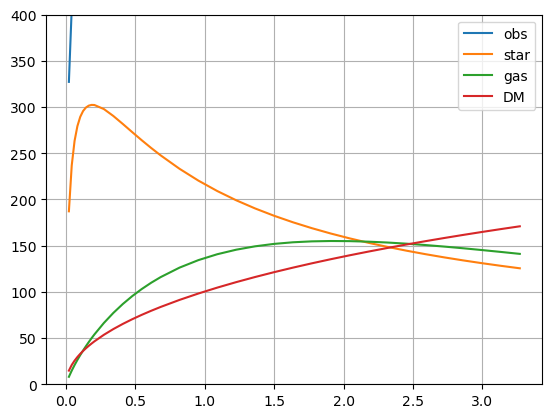

In [ ]:
plt.plot(rad_kpc, vel_obs, label="obs")
plt.plot(rad_kpc, vel_star, label="star")
plt.plot(rad_kpc, vel_gas, label="gas")
plt.plot(rad_kpc, vel_dm, label="DM")
plt.legend()
plt.grid()
plt.ylim(0,400)

In [18]:
from dynesty import plotting as dyplot

res = sampler.resultsa
res.summary()

Summary
niter: 24944
ncall: 554948
eff(%):  3.462
logz: -10.149 +/-  0.069


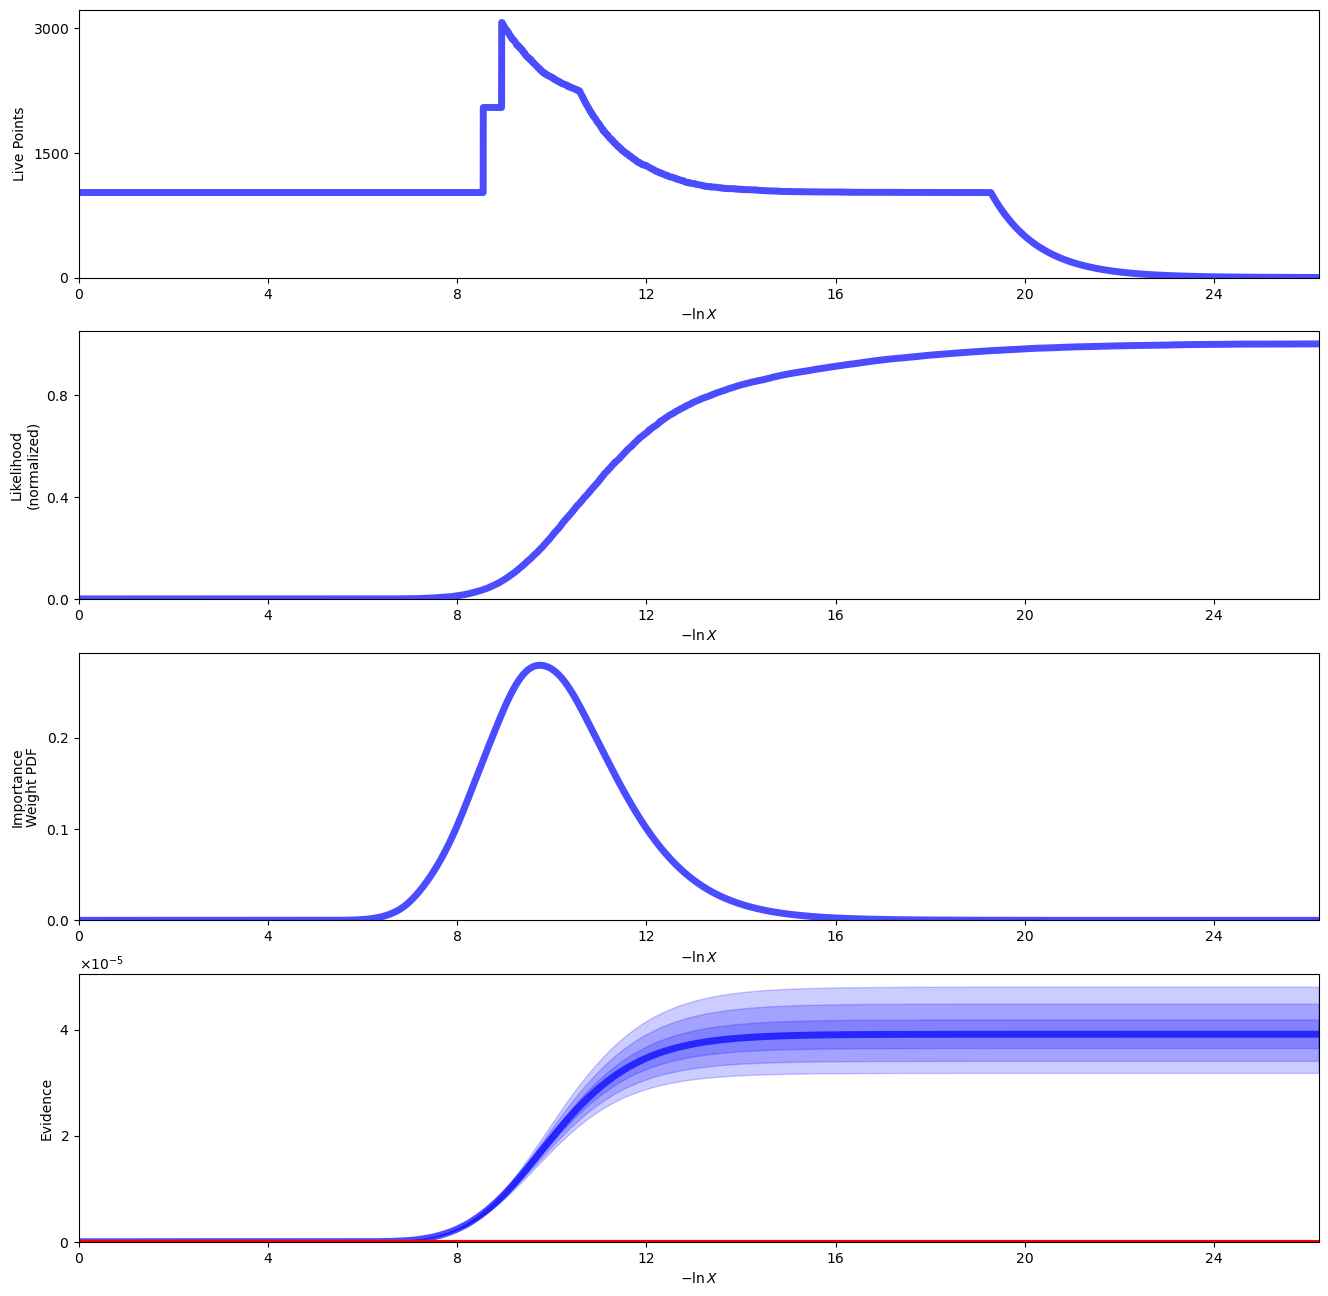

In [23]:
ndim = 6
lnz_truth = 6 * -np.log(20)
fig, axes = dyplot.runplot(res, lnz_truth=lnz_truth)

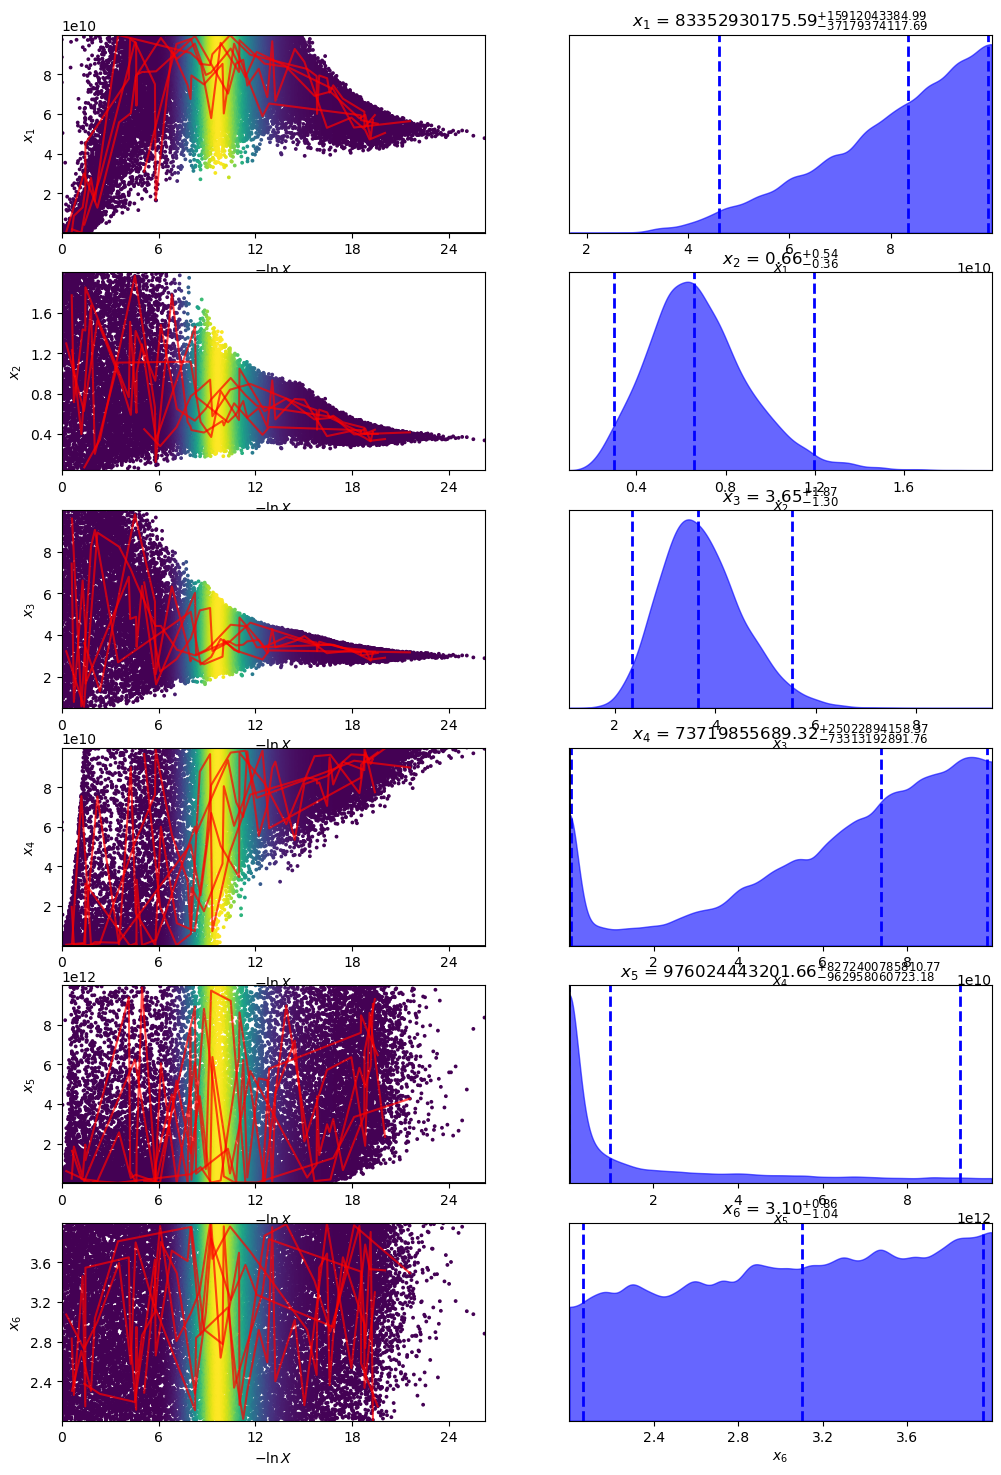

In [24]:
fig, axes = dyplot.traceplot(res, truths=np.zeros(ndim),
                             truth_color='black', show_titles=True,
                             trace_cmap='viridis', connect=True,
                             connect_highlight=range(5))

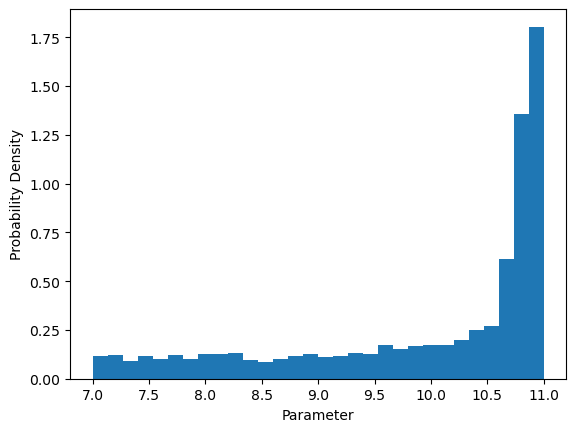

In [30]:
import matplotlib.pyplot as plt

# あるパラメータに対する重み付きヒストグラム
plt.hist(np.log10(res.samples[:, 0]), bins=30, weights=res.logwt, density=True)
plt.xlabel('Parameter')
plt.ylabel('Probability Density')
plt.show()
